# Waze User Churn Prediction

### Advanced Data Analytics and Machine Learning Project

Predicting monthly user churn from user activity and driving behavior data.

**Tools:** Python, Pandas, NumPy, Scikit Learn, XGBoost, Matplotlib, Seaborn

**Project Context:** Google Advanced Data Analytics Professional Certificate

> The Waze scenario and the dataset used in this project are fictitious and were created for educational purposes.

## Executive Summary

The goal of this project is to predict whether a user is retained or churned during a month. The dataset contains 14,299 labeled users, with churn representing 17.74% of the labeled observations.

I started with exploratory analysis and a device comparison, then built several behavioral features and trained three models: Logistic Regression, Random Forest, and XGBoost. The data was split into training, validation, and test sets so that model selection and threshold tuning could be done without using the final test set.

Among the two ensemble models, XGBoost had the higher validation recall and was used as the final model. At the default 0.50 threshold, its test recall was 0.1716, with 0.4555 precision, 0.2493 F1, and 0.7318 ROC AUC.

I also tested a lower threshold using the validation set. A threshold of 0.223 produced 0.503 recall on validation data. When that frozen threshold was applied to the test set, recall increased to 0.5247 and F1 to 0.4266, while precision fell to 0.3595 and accuracy to 0.7500.

The results show that the available behavior data contains useful signal, but it is not enough to identify all churners reliably. The threshold is therefore an operating choice, not a claim about the best production setting. A real deployment would need more detailed data and a business-defined cost for false positives and missed churners.

## 1. Business Problem

### Background

The project looks at monthly user churn as part of a retention problem. If users who are likely to leave can be identified early enough, they can be considered for a retention workflow.

### Problem Statement

The task is to predict whether a user is **retained** or **churned** using the behavioral information available in the dataset.

### Questions

1. What patterns are visible in the user activity data?
2. Is there a statistically significant difference in average monthly drives between iPhone and Android users?
3. Do the engineered behavioral features add useful information?
4. How do Logistic Regression, Random Forest, and XGBoost perform on the same prediction task?
5. What happens when the classification threshold is changed?

### Evaluation

Accuracy, precision, recall, F1, ROC AUC, and confusion matrices are used to evaluate the models. Recall is given extra attention because the practical goal is to identify as many potential churners as possible.

The test set is kept out of model selection and threshold tuning.

## 2. Data Loading and Initial Inspection

The raw dataset contains user level information collected over a monthly period. I load it first without changing the original columns, then handle cleaning and feature creation in later steps.

Keeping the loading step separate makes it easier to trace where each change in the dataset comes from.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report
)

from xgboost import XGBClassifier

import pickle
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


In [2]:
# Load the dataset
DATA_PATH = Path(r"waze_dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Update DATA_PATH to the location of waze_dataset.csv on your computer."
    )

df_raw = pd.read_csv(DATA_PATH)

print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]:,}")

df_raw.head()


Rows: 14,999
Columns: 13


,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


### Dataset Structure

The first checks look at the columns, data types, and the number of available observations. This gives a quick view of what is available before making any modeling decisions.

In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  str    
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  str    
dtypes: float64(3), int64(8), str(2)
memory usage: 1.5 MB


In [4]:
df_raw.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,14999.0,NaN,NaN,NaN,7499.0,4329.982679,0.0,3749.5,7499.0,11248.5,14998.0
label,14299,2,retained,11763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sessions,14999.0,NaN,NaN,NaN,80.633776,80.699065,0.0,23.0,56.0,112.0,743.0
drives,14999.0,NaN,NaN,NaN,67.281152,65.913872,0.0,20.0,48.0,93.0,596.0
total_sessions,14999.0,NaN,NaN,NaN,189.964447,136.405128,0.220211,90.661156,159.568115,254.192341,1216.154633
n_days_after_onboarding,14999.0,NaN,NaN,NaN,1749.837789,1008.513876,4.0,878.0,1741.0,2623.5,3500.0
total_navigations_fav1,14999.0,NaN,NaN,NaN,121.605974,148.121544,0.0,9.0,71.0,178.0,1236.0
total_navigations_fav2,14999.0,NaN,NaN,NaN,29.672512,45.394651,0.0,0.0,9.0,43.0,415.0
driven_km_drives,14999.0,NaN,NaN,NaN,4039.340921,2502.149334,60.44125,2212.600607,3493.858085,5289.861262,21183.40189
duration_minutes_drives,14999.0,NaN,NaN,NaN,1860.976012,1446.702288,18.282082,835.99626,1478.249859,2464.362632,15851.72716


### Missing Values

The target contains missing values in the original data. Those rows cannot be used for supervised learning because their churn status is unknown.

They are removed from the modeling dataset, while the remaining columns are checked separately rather than dropping rows automatically.

In [5]:
missing_summary = (
    df_raw.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary


,missing_count
label,700


In [6]:
df = df_raw.copy()

rows_before = len(df)
df = df.dropna(subset=["label"]).copy()

print(f"Rows before removing missing labels: {rows_before:,}")
print(f"Rows after removing missing labels: {len(df):,}")
print(f"Rows removed: {rows_before - len(df):,}")


Rows before removing missing labels: 14,999
Rows after removing missing labels: 14,299
Rows removed: 700


### Duplicate Records

I check for fully duplicated rows before moving into the analysis. Duplicate observations can give some users more influence than others during both analysis and model training.

In [7]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")


Duplicate rows: 0


## 3. Exploratory Data Analysis

The EDA looks at user activity, driving behavior, device type, and the churn distribution. The main purpose here is to understand the data well enough to decide what should go into the models.

### Churn Distribution

Churn is the minority class in this dataset. Because of that, accuracy by itself can hide how many churners the model is actually missing. Precision, recall, and F1 are therefore reported alongside accuracy.

In [8]:
churn_distribution = df["label"].value_counts()
churn_proportion = df["label"].value_counts(normalize=True).mul(100).round(2)

print(churn_distribution)
print()
print(churn_proportion)


label
retained    11763
churned      2536
Name: count, dtype: int64

label
retained    82.26
churned     17.74
Name: proportion, dtype: float64


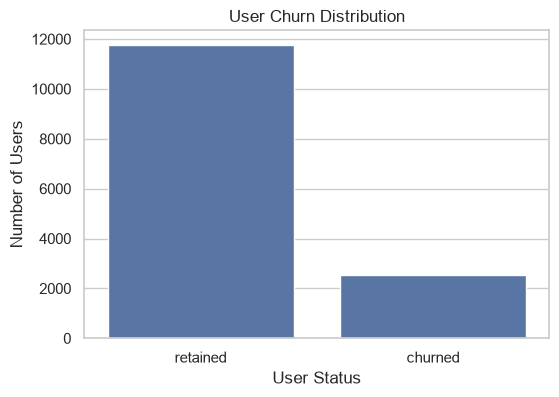

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("User Churn Distribution")
plt.xlabel("User Status")
plt.ylabel("Number of Users")
plt.show()


The cleaned data contains a relatively small churned group compared with retained users. This class imbalance is one reason recall is important later in the modeling stage.

### Activity and Driving Behavior

Several activity variables are strongly right skewed. The distribution plots and medians are useful here because a small number of high activity users can pull the mean upward.

In [10]:
activity_columns = [
    "sessions",
    "drives",
    "total_sessions",
    "driven_km_drives",
    "duration_minutes_drives",
    "activity_days",
    "driving_days"
]

df[activity_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
sessions,14299.0,80.623820,80.736502,0.000000,23.000000,56.000000,111.000000,743.000000
drives,14299.0,67.255822,65.947295,0.000000,20.000000,48.000000,93.000000,596.000000
total_sessions,14299.0,189.547409,136.189764,0.220211,90.457733,158.718571,253.540450,1216.154633
driven_km_drives,14299.0,4044.401535,2504.977970,60.441250,2217.319909,3496.545617,5299.972162,21183.401890
duration_minutes_drives,14299.0,1864.199794,1448.005047,18.282082,840.181344,1479.394387,2466.928876,15851.727160
activity_days,14299.0,15.544653,9.016088,0.000000,8.000000,16.000000,23.000000,31.000000
driving_days,14299.0,12.182530,7.833835,0.000000,5.000000,12.000000,19.000000,30.000000


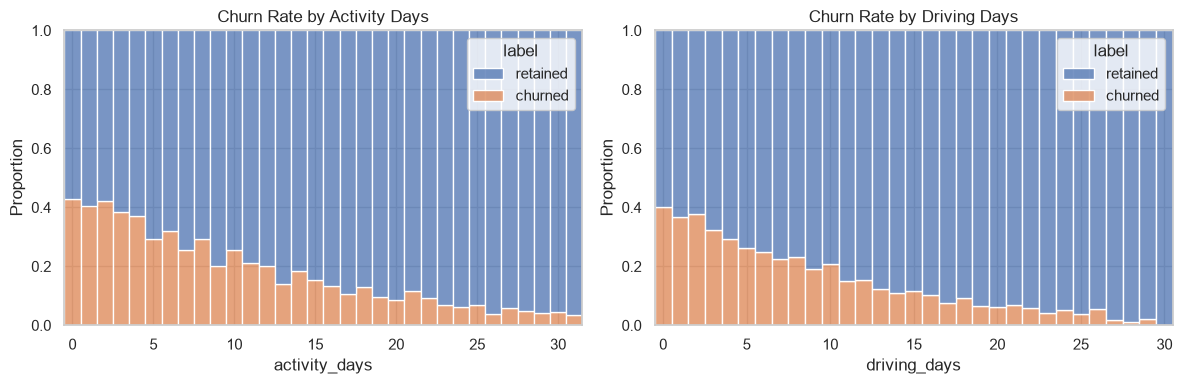

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="activity_days", hue="label",
             multiple="fill", discrete=True, ax=axes[0])
axes[0].set_title("Churn Rate by Activity Days")
axes[0].set_ylabel("Proportion")

sns.histplot(data=df, x="driving_days", hue="label",
             multiple="fill", discrete=True, ax=axes[1])
axes[1].set_title("Churn Rate by Driving Days")
axes[1].set_ylabel("Proportion")

plt.tight_layout()
plt.show()


Users with fewer driving days tend to have higher churn rates in the observed data, while users with more frequent activity tend to have lower churn rates.

This is a pattern in the dataset, not evidence that increasing driving activity would cause churn to fall.

### Retention by Device

The dataset contains both iPhone and Android users. I compare their monthly driving activity first descriptively, then use a statistical test to check whether the difference in average drives is statistically significant.

In [12]:
device_summary = (
    df.groupby("device")["drives"]
    .agg(["count", "mean", "median"])
)

device_summary


,count,mean,median
device,,,
Android,5074,66.024241,47.0
iPhone,9225,67.933225,48.0


In [13]:
device_churn = pd.crosstab(
    df["device"],
    df["label"],
    normalize="index"
).mul(100).round(2)

device_churn


label,churned,retained
device,,
Android,17.56,82.44
iPhone,17.83,82.17


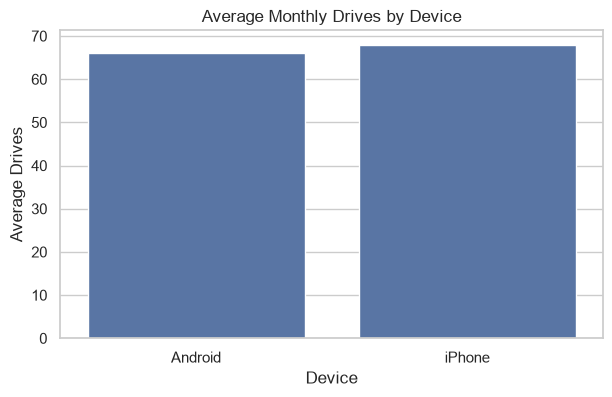

In [14]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="device", y="drives", errorbar=None)
plt.title("Average Monthly Drives by Device")
plt.xlabel("Device")
plt.ylabel("Average Drives")
plt.show()


The device comparison is useful as a first look, but the difference between two sample means should not be treated as a population level difference without a statistical test.

## 4. Statistical Analysis

### Research Question

Is there a statistically significant difference in the average number of monthly drives between iPhone and Android users?

### Hypotheses

**H₀:** There is no difference in average monthly drives between the two device groups.

**H₁:** There is a difference in average monthly drives between the two device groups.

A Welch two sample t test is used because it does not assume equal variances between the groups.

In [15]:
iphone_drives = df.loc[df["device"] == "iPhone", "drives"]
android_drives = df.loc[df["device"] == "Android", "drives"]

ttest_result = stats.ttest_ind(
    iphone_drives,
    android_drives,
    equal_var=False
)

print(f"iPhone mean drives: {iphone_drives.mean():.2f}")
print(f"Android mean drives: {android_drives.mean():.2f}")
print(f"t statistic: {ttest_result.statistic:.4f}")
print(f"p value: {ttest_result.pvalue:.6f}")


iPhone mean drives: 67.93
Android mean drives: 66.02
t statistic: 1.6766
p value: 0.093651


### Statistical Conclusion

The significance level is set to 0.05. The test result is interpreted by comparing the p value with this level.

The test is about the difference in average drives between the two device groups. It does not show that device type causes differences in driving behavior or churn.

In [16]:
alpha = 0.05

if ttest_result.pvalue < alpha:
    print("Result: Reject H0. The difference in average monthly drives is statistically significant at the 5% level.")
else:
    print("Result: Fail to reject H0. There is not sufficient evidence of a statistically significant difference in average monthly drives at the 5% level.")


Result: Fail to reject H0. There is not sufficient evidence of a statistically significant difference in average monthly drives at the 5% level.


## 5. Feature Engineering

A few ratios and indicators are created to describe behavior in a more direct way than the raw counts alone.

The engineered features are:

* `km_per_driving_day`: distance driven per driving day
* `percent_sessions_in_last_month`: recent sessions relative to total sessions
* `professional_driver`: 1 for users with at least 60 drives and at least 15 driving days
* `total_sessions_per_day`: average sessions per day since onboarding
* `km_per_hour`: average recorded driving speed
* `km_per_drive`: average distance per drive
* `percent_of_drives_to_favorite`: favorite navigation activity relative to total sessions
* `drives_per_session`: drives relative to sessions

The calculations explicitly handle zero denominators so that the new columns do not contain infinite values.

In [17]:
# Distance per driving day
df["km_per_driving_day"] = np.divide(
    df["driven_km_drives"],
    df["driving_days"],
    out=np.zeros(len(df), dtype=float),
    where=df["driving_days"].ne(0)
)

# Recent sessions relative to total sessions
df["percent_sessions_in_last_month"] = np.divide(
    df["sessions"],
    df["total_sessions"],
    out=np.zeros(len(df), dtype=float),
    where=df["total_sessions"].ne(0)
)

# Professional driver indicator
df["professional_driver"] = np.where(
    (df["drives"] >= 60) & (df["driving_days"] >= 15),
    1,
    0
)

# Average sessions per day since onboarding
df["total_sessions_per_day"] = np.divide(
    df["total_sessions"],
    df["n_days_after_onboarding"],
    out=np.zeros(len(df), dtype=float),
    where=df["n_days_after_onboarding"].ne(0)
)

# Average kilometers per hour
df["km_per_hour"] = np.divide(
    df["driven_km_drives"],
    df["duration_minutes_drives"] / 60,
    out=np.zeros(len(df), dtype=float),
    where=df["duration_minutes_drives"].ne(0)
)

# Average kilometers per drive
df["km_per_drive"] = np.divide(
    df["driven_km_drives"],
    df["drives"],
    out=np.zeros(len(df), dtype=float),
    where=df["drives"].ne(0)
)

# Favorite navigation activity relative to total sessions
df["percent_of_drives_to_favorite"] = np.divide(
    df["total_navigations_fav1"] + df["total_navigations_fav2"],
    df["total_sessions"],
    out=np.zeros(len(df), dtype=float),
    where=df["total_sessions"].ne(0)
)

# Monthly drives relative to monthly sessions
df["drives_per_session"] = np.divide(
    df["drives"],
    df["sessions"],
    out=np.zeros(len(df), dtype=float),
    where=df["sessions"].ne(0)
)

engineered_features = [
    "km_per_driving_day",
    "percent_sessions_in_last_month",
    "professional_driver",
    "total_sessions_per_day",
    "km_per_hour",
    "km_per_drive",
    "percent_of_drives_to_favorite",
    "drives_per_session"
]

df[engineered_features].describe().T


,count,mean,std,min,25%,50%,75%,max
km_per_driving_day,14299.0,581.942399,1038.254509,0.000000,136.168003,273.301012,558.018761,15420.234110
percent_sessions_in_last_month,14299.0,0.449837,0.286863,0.000000,0.196890,0.424310,0.687251,1.530637
professional_driver,14299.0,0.173998,0.379121,0.000000,0.000000,0.000000,0.000000,1.000000
total_sessions_per_day,14299.0,0.338207,1.319814,0.000298,0.050818,0.100457,0.215210,39.763874
km_per_hour,14299.0,190.730963,339.926138,72.013095,90.649402,122.105845,193.238449,23642.920871
km_per_drive,14299.0,232.269197,616.197409,0.000000,32.486524,72.947059,179.347527,15777.426560
percent_of_drives_to_favorite,14299.0,1.676347,9.021250,0.000000,0.206064,0.653572,1.643183,777.563629
drives_per_session,14299.0,0.853862,0.105923,0.000000,0.803922,0.820513,0.900000,1.000000


### Inspecting Engineered Features

Ratios can produce very large values, especially when the denominator is small. Before fitting the final models, extreme values are capped.

The important part is where the cap is calculated: the 95th percentile is estimated from the training set only, then the same thresholds are applied to validation and test data. This keeps information from the later splits out of preprocessing.

## 6. Preparing the Modeling Dataset

The target is encoded as:

* retained = 0
* churned = 1

`ID` is removed because it is an identifier rather than a behavioral predictor. The original `device` column is also replaced with the binary `device2` feature.

In [18]:
# Encode target
df["label2"] = np.where(df["label"] == "churned", 1, 0)

# Encode device
df["device2"] = np.where(df["device"] == "iPhone", 1, 0)

# Remove non predictive identifier and original categorical columns
model_df = df.drop(columns=["ID", "label", "device"]).copy()

X = model_df.drop(columns=["label2"])
y = model_df["label2"]

print(f"Modeling rows: {len(X):,}")
print(f"Modeling features: {X.shape[1]:,}")


Modeling rows: 14,299
Modeling features: 19


### Class Balance

Churn is the minority class, so the data is split with stratification. This keeps the retained and churned proportions reasonably consistent across the three splits.

In [19]:
class_balance = y.value_counts(normalize=True).rename(index={0: "retained", 1: "churned"})
class_balance


label2
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64

## 7. Train, Validation, and Test Split

The data is divided into roughly 60% training, 20% validation, and 20% test.

The training set is used to fit models and run cross validation. The validation set is used for model comparison and threshold selection. The test set is saved for the final check after those decisions are frozen.

In [20]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f"Training rows:   {len(X_train):,}")
print(f"Validation rows: {len(X_val):,}")
print(f"Test rows:       {len(X_test):,}")


Training rows:   8,579
Validation rows: 2,860
Test rows:       2,860


### Training Only Outlier Capping

The 95th percentile thresholds are calculated from `X_train` only. The same thresholds are then applied to `X_val` and `X_test`.

Calculating a threshold from the full dataset would let information from the validation or test sets influence the preprocessing step.

In [21]:
outlier_columns = [
    "sessions",
    "drives",
    "total_sessions",
    "total_navigations_fav1",
    "total_navigations_fav2",
    "driven_km_drives",
    "duration_minutes_drives",
    "km_per_driving_day",
    "percent_sessions_in_last_month",
    "total_sessions_per_day",
    "km_per_hour",
    "km_per_drive",
    "percent_of_drives_to_favorite",
    "drives_per_session"
]

cap_thresholds = {}

for column in outlier_columns:
    threshold = X_train[column].quantile(0.95)
    cap_thresholds[column] = threshold

    X_train[column] = (
        X_train[column].astype(float).clip(upper=threshold)
    )

    X_val[column] = (
        X_val[column].astype(float).clip(upper=threshold)
    )

    X_test[column] = (
        X_test[column].astype(float).clip(upper=threshold)
    )

cap_thresholds_df = pd.Series(
    cap_thresholds,
    name="95th_percentile_threshold"
)

cap_thresholds_df


sessions                           243.000000
drives                             200.000000
total_sessions                     455.771636
total_navigations_fav1             421.000000
total_navigations_fav2             121.100000
driven_km_drives                  8879.081958
duration_minutes_drives           4657.970660
km_per_driving_day                2189.946947
percent_sessions_in_last_month       0.936294
total_sessions_per_day               1.061167
km_per_hour                        478.211521
km_per_drive                       945.096637
percent_of_drives_to_favorite        5.465619
drives_per_session                   1.000000
Name: 95th_percentile_threshold, dtype: float64

## 8. Logistic Regression Baseline

Logistic Regression is used as a simple baseline. The numerical features are standardized before fitting because the variables are measured on very different scales.

Its validation results give a reference point for the two tree based models.

In [22]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_pipeline.fit(X_train, y_train)

logistic_val_pred = logistic_pipeline.predict(X_val)
logistic_val_prob = logistic_pipeline.predict_proba(X_val)[:, 1]


In [23]:
def classification_metrics(y_true, predictions, probabilities=None, model_name="Model"):
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0)
    }

    if probabilities is not None:
        metrics["ROC AUC"] = roc_auc_score(y_true, probabilities)

    return pd.DataFrame([metrics])

logistic_val_results = classification_metrics(
    y_val,
    logistic_val_pred,
    logistic_val_prob,
    "Logistic Regression"
)

logistic_val_results


,model,accuracy,precision,recall,F1,ROC AUC
0,Logistic Regression,0.826923,0.568182,0.098619,0.168067,0.741554


              precision    recall  f1-score   support

    retained       0.84      0.98      0.90      2353
     churned       0.57      0.10      0.17       507

    accuracy                           0.83      2860
   macro avg       0.70      0.54      0.54      2860
weighted avg       0.79      0.83      0.77      2860



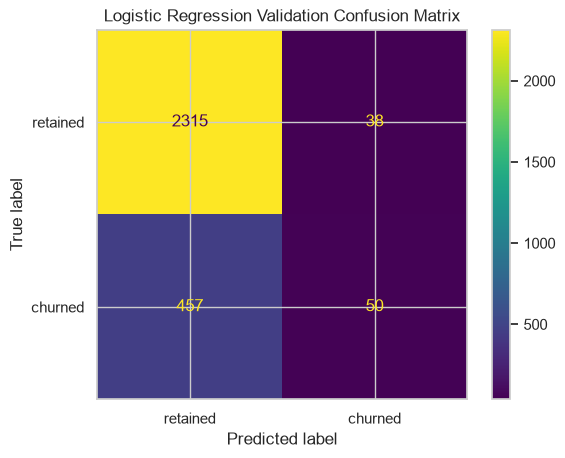

In [24]:
print(classification_report(
    y_val,
    logistic_val_pred,
    target_names=["retained", "churned"],
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    logistic_val_pred,
    display_labels=["retained", "churned"]
)
plt.title("Logistic Regression Validation Confusion Matrix")
plt.show()


The baseline is not expected to capture every nonlinear relationship in the data. Random Forest and XGBoost are added next because they can model nonlinear patterns and feature interactions without requiring the same linear assumptions.

## 9. Random Forest

Random Forest is tuned with cross validation. Recall is used as the refit metric because the modeling objective puts emphasis on detecting churners.

The grid contains several combinations of tree depth, feature sampling, and minimum leaf size rather than relying on a single hand picked configuration.

In [25]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [200],
    "max_depth": [None, 10],
    "max_features": ["sqrt", 0.7],
    "min_samples_leaf": [1, 2]
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

rf_cv = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    scoring=scoring,
    refit="recall",
    cv=4,
    n_jobs=-1,
    return_train_score=False
)


In [26]:
%%time
rf_cv.fit(X_train, y_train)


CPU times: total: 19.6 s
Wall time: 1min 41s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10], 'max_features': ['sqrt', 0.7], 'min_samples_leaf': [1, 2], 'n_estimators': [200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``c

In [27]:
rf_cv.best_params_, rf_cv.best_score_


({'max_depth': None,
  'max_features': 0.7,
  'min_samples_leaf': 2,
  'n_estimators': 200},
 np.float64(0.12879541373117834))

In [28]:
rf_cv_results = pd.DataFrame(rf_cv.cv_results_)

rf_cv_summary = rf_cv_results[[
    "params",
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1"
]].sort_values("mean_test_recall", ascending=False)

rf_cv_summary


,params,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1
3,"{'max_depth': None, 'max_features': 0.7, 'min_...",0.818160,0.457753,0.128795,0.200126
2,"{'max_depth': None, 'max_features': 0.7, 'min_...",0.817578,0.450435,0.128136,0.198929
7,"{'max_depth': 10, 'max_features': 0.7, 'min_sa...",0.822706,0.508742,0.122220,0.196086
6,"{'max_depth': 10, 'max_features': 0.7, 'min_sa...",0.821774,0.491593,0.113688,0.183150
1,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.822590,0.500340,0.113686,0.184672
0,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.822007,0.490918,0.110397,0.179751
4,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.823522,0.513615,0.091345,0.154407
5,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.824105,0.530351,0.088046,0.150681


In [29]:
rf_val_pred = rf_cv.best_estimator_.predict(X_val)
rf_val_prob = rf_cv.best_estimator_.predict_proba(X_val)[:, 1]

rf_val_results = classification_metrics(
    y_val,
    rf_val_pred,
    rf_val_prob,
    "Random Forest"
)

rf_val_results


,model,accuracy,precision,recall,F1,ROC AUC
0,Random Forest,0.819231,0.458333,0.108481,0.175439,0.696703


              precision    recall  f1-score   support

    retained       0.84      0.97      0.90      2353
     churned       0.46      0.11      0.18       507

    accuracy                           0.82      2860
   macro avg       0.65      0.54      0.54      2860
weighted avg       0.77      0.82      0.77      2860



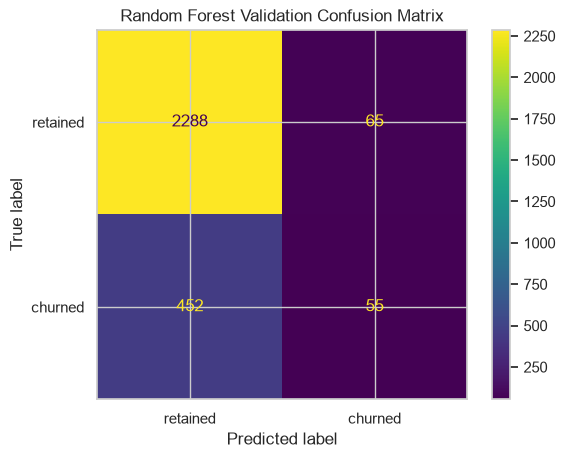

In [30]:
print(classification_report(
    y_val,
    rf_val_pred,
    target_names=["retained", "churned"],
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    rf_val_pred,
    display_labels=["retained", "churned"]
)
plt.title("Random Forest Validation Confusion Matrix")
plt.show()


### Random Forest Validation Findings

The optimized Random Forest reaches 0.8192 accuracy, 0.4583 precision, 0.1085 recall, 0.1754 F1, and 0.6967 ROC AUC on the validation set.

The accuracy is relatively high because retained users are the majority class, but the recall shows that the model misses many of the users who churn. That is why accuracy alone is not enough for this problem.

## 10. XGBoost

XGBoost is evaluated using the same train and validation setup. Its hyperparameters are tuned with cross validation, again using recall as the refit metric.

This keeps the model comparison focused on the same practical objective.

In [31]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_params = {
    "max_depth": [4, 6],
    "min_child_weight": [3, 5],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200]
}

xgb_cv = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    scoring=scoring,
    refit="recall",
    cv=4,
    n_jobs=-1,
    return_train_score=False
)


In [32]:
%%time
xgb_cv.fit(X_train, y_train)


CPU times: total: 4.23 s
Wall time: 18.4 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [4, 6], 'min_child_weight': [3, 5], 'n_estimators': [200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv``

In [33]:
xgb_cv.best_params_, xgb_cv.best_score_


({'learning_rate': 0.1,
  'max_depth': 6,
  'min_child_weight': 5,
  'n_estimators': 200},
 np.float64(0.15902403646912558))

In [34]:
xgb_cv_results = pd.DataFrame(xgb_cv.cv_results_)

xgb_cv_summary = xgb_cv_results[[
    "params",
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1"
]].sort_values("mean_test_recall", ascending=False)

xgb_cv_summary


,params,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1
7,"{'learning_rate': 0.1, 'max_depth': 6, 'min_ch...",0.815362,0.446586,0.159024,0.233082
6,"{'learning_rate': 0.1, 'max_depth': 6, 'min_ch...",0.813031,0.427792,0.153757,0.225420
5,"{'learning_rate': 0.1, 'max_depth': 4, 'min_ch...",0.819908,0.477232,0.149822,0.227305
3,"{'learning_rate': 0.05, 'max_depth': 6, 'min_c...",0.820258,0.480575,0.144562,0.221475
4,"{'learning_rate': 0.1, 'max_depth': 4, 'min_ch...",0.817694,0.455653,0.141938,0.215947
2,"{'learning_rate': 0.05, 'max_depth': 6, 'min_c...",0.818743,0.466607,0.136675,0.210108
1,"{'learning_rate': 0.05, 'max_depth': 4, 'min_c...",0.822823,0.505543,0.130115,0.205934
0,"{'learning_rate': 0.05, 'max_depth': 4, 'min_c...",0.822823,0.506311,0.124858,0.199245


In [35]:
xgb_val_pred = xgb_cv.best_estimator_.predict(X_val)
xgb_val_prob = xgb_cv.best_estimator_.predict_proba(X_val)[:, 1]

xgb_val_results = classification_metrics(
    y_val,
    xgb_val_pred,
    xgb_val_prob,
    "XGBoost"
)

xgb_val_results


,model,accuracy,precision,recall,F1,ROC AUC
0,XGBoost,0.812238,0.411765,0.138067,0.206795,0.698175


              precision    recall  f1-score   support

    retained       0.84      0.96      0.89      2353
     churned       0.41      0.14      0.21       507

    accuracy                           0.81      2860
   macro avg       0.62      0.55      0.55      2860
weighted avg       0.76      0.81      0.77      2860



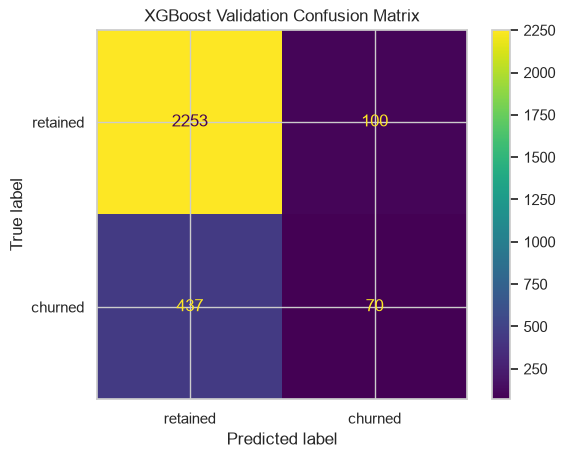

In [36]:
print(classification_report(
    y_val,
    xgb_val_pred,
    target_names=["retained", "churned"],
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    xgb_val_pred,
    display_labels=["retained", "churned"]
)
plt.title("XGBoost Validation Confusion Matrix")
plt.show()


## 11. Model Comparison and Selection

The validation results are compared before looking at the test set. Logistic Regression is kept as the baseline, while Random Forest and XGBoost are the two ensemble candidates.

For the final ensemble choice, validation recall is the primary criterion and F1 is used as a secondary tie breaker. The test set is not involved in this decision.

In [37]:
validation_results = pd.concat(
    [
        logistic_val_results,
        rf_val_results,
        xgb_val_results
    ],
    ignore_index=True
)

validation_results.sort_values(
    by=["recall", "F1"],
    ascending=False
)


,model,accuracy,precision,recall,F1,ROC AUC
2,XGBoost,0.812238,0.411765,0.138067,0.206795,0.698175
1,Random Forest,0.819231,0.458333,0.108481,0.175439,0.696703
0,Logistic Regression,0.826923,0.568182,0.098619,0.168067,0.741554


In [38]:
# Select the ensemble model using validation recall.
ensemble_results = pd.concat(
    [rf_val_results, xgb_val_results],
    ignore_index=True
)

champion_name = ensemble_results.sort_values(
    by=["recall", "F1"],
    ascending=False
).iloc[0]["model"]

if champion_name == "Random Forest":
    champion_model = rf_cv.best_estimator_
else:
    champion_model = xgb_cv.best_estimator_

print(f"Champion model based on validation recall: {champion_name}")


Champion model based on validation recall: XGBoost


In [39]:
# Generate validation probabilities for threshold selection.
champion_val_prob = champion_model.predict_proba(X_val)[:, 1]

print(f"Validation probabilities generated for: {champion_name}")
print(f"Number of validation predictions: {len(champion_val_prob)}")

Validation probabilities generated for: XGBoost
Number of validation predictions: 2860


## 12. Decision Threshold Optimization

A classification model does not have to use 0.50 as its decision threshold. Lowering the threshold means more users are labeled as potential churners. That usually increases recall, but it also increases false positives and can reduce precision.

Here the threshold is selected from validation probabilities only. I use a target recall of 0.50 as an analytical operating point. This is not a production requirement. In a real retention workflow, the threshold should be based on the relative cost of missed churners and unnecessary outreach.

### Precision Recall Curve

The precision recall curve shows how precision changes as recall changes across possible thresholds.

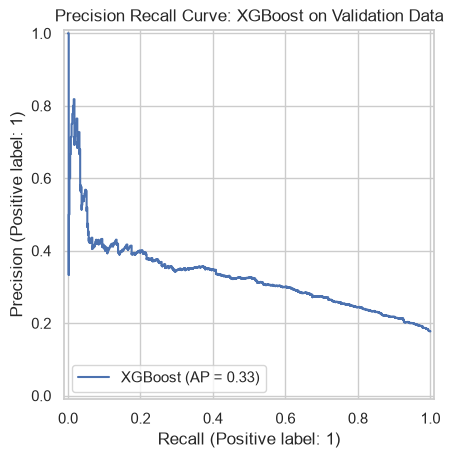

In [40]:
PrecisionRecallDisplay.from_predictions(
    y_val,
    champion_val_prob,
    name=champion_name
)
plt.title(f"Precision Recall Curve: {champion_name} on Validation Data")
plt.show()


The threshold search looks for the value closest to a target recall of 0.50 on the validation set. The selected threshold is then frozen before the test set is evaluated.

In [41]:
def find_threshold_for_recall(y_true, probabilities, target_recall=0.50):
    thresholds = np.arange(0.01, 1.00, 0.001)
    records = []

    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        records.append({
            "threshold": threshold,
            "precision": precision_score(y_true, predictions, zero_division=0),
            "recall": recall_score(y_true, predictions, zero_division=0),
            "F1": f1_score(y_true, predictions, zero_division=0)
        })

    threshold_table = pd.DataFrame(records)
    threshold_table["recall_distance"] = (
        threshold_table["recall"] - target_recall
    ).abs()

    selected = threshold_table.sort_values(
        ["recall_distance", "F1"],
        ascending=[True, False]
    ).iloc[0]

    return float(selected["threshold"]), threshold_table

selected_threshold, threshold_table = find_threshold_for_recall(
    y_val,
    champion_val_prob,
    target_recall=0.50
)

selected_row = threshold_table.loc[
    threshold_table["threshold"] == selected_threshold
].iloc[0]

print(f"Selected threshold: {selected_threshold:.3f}")
print(f"Validation precision: {selected_row['precision']:.3f}")
print(f"Validation recall: {selected_row['recall']:.3f}")
print(f"Validation F1: {selected_row['F1']:.3f}")


Selected threshold: 0.223
Validation precision: 0.327
Validation recall: 0.503
Validation F1: 0.396


In [42]:
# Compare the default threshold with the selected threshold on validation data
default_val_pred = (champion_val_prob >= 0.50).astype(int)
tuned_val_pred = (champion_val_prob >= selected_threshold).astype(int)

threshold_comparison = pd.concat([
    classification_metrics(
        y_val,
        default_val_pred,
        champion_val_prob,
        f"{champion_name}, threshold = 0.50"
    ),
    classification_metrics(
        y_val,
        tuned_val_pred,
        champion_val_prob,
        f"{champion_name}, threshold = {selected_threshold:.3f}"
    )
], ignore_index=True)

threshold_comparison


,model,accuracy,precision,recall,F1,ROC AUC
0,"XGBoost, threshold = 0.50",0.812238,0.411765,0.138067,0.206795,0.698175
1,"XGBoost, threshold = 0.223",0.727972,0.326504,0.502959,0.395963,0.698175


## 13. Final Test Evaluation

At this point the model and threshold have both been selected. The test data is used only now to estimate how the frozen setup performs on unseen observations.

Two operating points are shown: the default threshold of 0.50 and the threshold selected from validation.

In [43]:
champion_test_prob = champion_model.predict_proba(X_test)[:, 1]

default_test_pred = (champion_test_prob >= 0.50).astype(int)
tuned_test_pred = (champion_test_prob >= selected_threshold).astype(int)

final_test_results = pd.concat([
    classification_metrics(
        y_test,
        default_test_pred,
        champion_test_prob,
        f"{champion_name}, threshold = 0.50"
    ),
    classification_metrics(
        y_test,
        tuned_test_pred,
        champion_test_prob,
        f"{champion_name}, threshold = {selected_threshold:.3f}"
    )
], ignore_index=True)

final_test_results


,model,accuracy,precision,recall,F1,ROC AUC
0,"XGBoost, threshold = 0.50",0.816783,0.455497,0.171598,0.249284,0.731807
1,"XGBoost, threshold = 0.223",0.750000,0.359459,0.524655,0.426624,0.731807


In [44]:
print("Final classification report using the selected validation threshold:")
print(classification_report(
    y_test,
    tuned_test_pred,
    target_names=["retained", "churned"],
    zero_division=0
))


Final classification report using the selected validation threshold:
              precision    recall  f1-score   support

    retained       0.89      0.80      0.84      2353
     churned       0.36      0.52      0.43       507

    accuracy                           0.75      2860
   macro avg       0.62      0.66      0.63      2860
weighted avg       0.79      0.75      0.77      2860



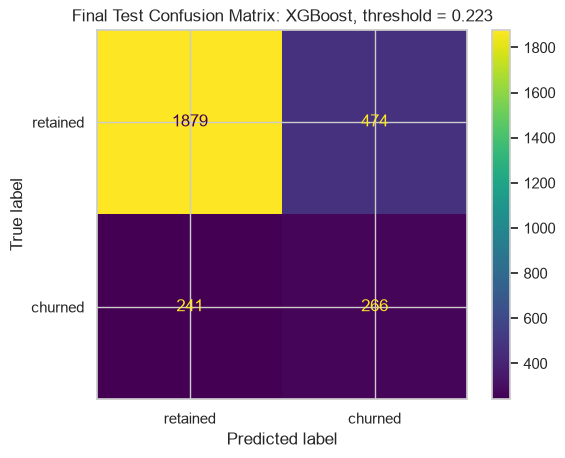

In [45]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_test_pred,
    display_labels=["retained", "churned"]
)
plt.title(
    f"Final Test Confusion Matrix: {champion_name}, "
    f"threshold = {selected_threshold:.3f}"
)
plt.show()


### Interpreting the Final Results

At 0.50, the XGBoost model gets 0.1716 recall on the test set. With the validation selected threshold of 0.223, recall rises to 0.5247 and F1 rises to 0.4266. The trade off is lower precision, from 0.4555 to 0.3595, and lower accuracy, from 0.8168 to 0.7500.

The lower threshold therefore changes the operating point rather than making the underlying model rank users better. ROC AUC stays at 0.7318 because it is calculated from the predicted probabilities across thresholds.

The 0.223 threshold should be viewed as an example operating point for this analysis, not as a recommended production threshold.

## 14. ROC and Precision Recall Analysis

ROC AUC measures how well the model ranks positive and negative cases across possible thresholds. The precision recall curve is also useful here because churn is the minority class.

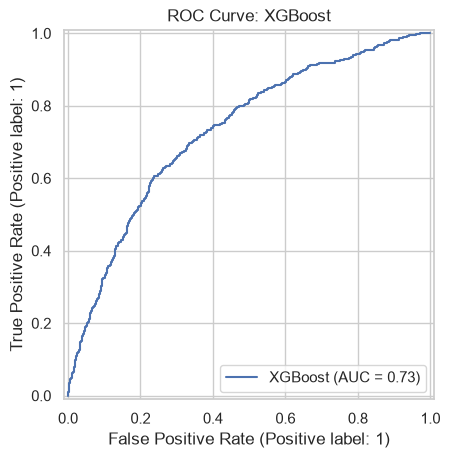

Final test ROC AUC: 0.7318


In [46]:
RocCurveDisplay.from_predictions(
    y_test,
    champion_test_prob,
    name=champion_name
)
plt.title(f"ROC Curve: {champion_name}")
plt.show()

print(f"Final test ROC AUC: {roc_auc_score(y_test, champion_test_prob):.4f}")


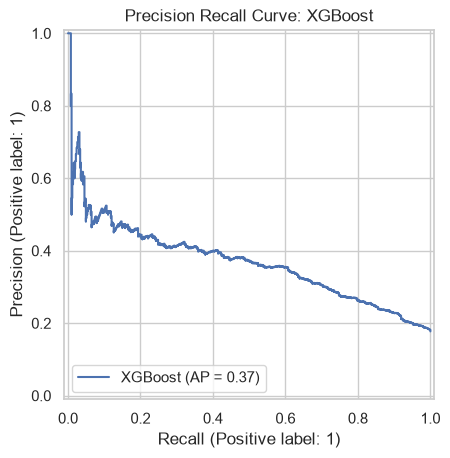

In [47]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    champion_test_prob,
    name=champion_name
)
plt.title(f"Precision Recall Curve: {champion_name}")
plt.show()


## 15. Feature Importance

The final XGBoost model provides feature importance values that show which predictors the model relied on most when building its trees.

These values describe model behavior. They do not prove that a feature causes churn.

In [48]:
if champion_name == "XGBoost":
    importance = pd.Series(
        champion_model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)
else:
    importance = pd.Series(
        champion_model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

importance.head(15)


activity_days                    0.249498
n_days_after_onboarding          0.057040
driving_days                     0.053031
total_navigations_fav1           0.048842
total_sessions_per_day           0.045523
sessions                         0.044558
drives                           0.042162
km_per_hour                      0.041976
percent_of_drives_to_favorite    0.041473
device2                          0.040916
duration_minutes_drives          0.040831
total_sessions                   0.040722
drives_per_session               0.040280
total_navigations_fav2           0.038475
km_per_driving_day               0.038401
dtype: float32

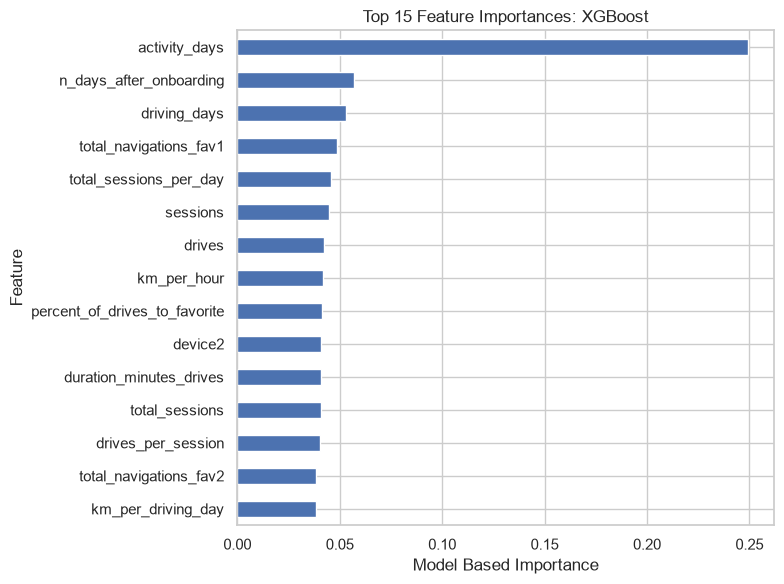

In [49]:
plt.figure(figsize=(8, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.title(f"Top 15 Feature Importances: {champion_name}")
plt.xlabel("Model Based Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Current Feature Importance

In the current XGBoost run, `activity_days` has the largest model based importance at 0.249498. The next features include `n_days_after_onboarding`, `driving_days`, `total_navigations_fav1`, and `total_sessions_per_day`.

Several engineered variables also appear in the top 15, including `total_sessions_per_day`, `km_per_hour`, `percent_of_drives_to_favorite`, `km_per_drive`, and `km_per_driving_day`.

The ranking comes from the current model output. It should not be read as a causal ranking of what makes users churn.

## 16. Key Findings

1. The modeling data contains 14,299 labeled users, and 17.74% of them are in the churned class.

2. The Welch test gives a p value of 0.093651 for the difference in average monthly drives between iPhone and Android users. At the 5% significance level, the result does not provide sufficient evidence of a statistically significant difference.

3. XGBoost is selected as the ensemble champion because its validation recall of 0.1381 is higher than the Random Forest recall of 0.1085.

4. At a 0.50 threshold, XGBoost reaches 0.1716 recall on the test set. The validation selected threshold of 0.223 raises test recall to 0.5247, while precision falls to 0.3595.

5. The final test ROC AUC is 0.7318. The model has useful ranking signal, but it still misses a substantial portion of churners at the default threshold.

6. `activity_days` is the most important feature in the current XGBoost model. Several engineered features also appear among the top 15 model based importance values.

7. The available data supports prediction to some extent, but it is not enough to explain the causes of churn.

## 17. Business Interpretation

The model can be used to create a list of users who appear more likely to churn, which could then be used to prioritize a retention workflow.

The threshold results show the trade off clearly. At 0.223, more actual churners are detected, but more retained users are also flagged. Whether that trade off makes sense depends on what a retention action costs and how valuable it is to catch an additional churner.

The predictions should be treated as risk estimates, not as statements that a particular user will definitely churn. Any retention action would also need a separate evaluation to see whether it actually improves retention.

## 18. Limitations and Data Gaps

The dataset and Waze scenario are simulated for educational purposes, so the model results should not be treated as real Waze performance.

The available variables are mostly monthly aggregates. More detailed information could add useful signal, such as drive level behavior, route or location patterns, road hazard interactions, and more detailed app usage.

The current model also works with the information available in this dataset at the same modeling point. A real deployment would need to confirm that every predictor is available before the prediction is made and that the same preprocessing can be applied consistently.

A future iteration should be tested on additional data collected under the intended prediction conditions.

## 19. Model Persistence

The trained Random Forest, XGBoost, and champion model are saved as pickle files. The saved artifacts also keep the feature order, training based outlier thresholds, target mapping, and the selected decision threshold for the champion model.

This makes it possible to reload the trained model without rerunning the full training process. The feature engineering steps still need to be applied consistently to any new data.

In [50]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

common_metadata = {
    "feature_columns": list(X_train.columns),
    "cap_thresholds": cap_thresholds,
    "target_mapping": {"retained": 0, "churned": 1},
    "default_threshold": 0.50
}

rf_artifact = {
    "model": rf_cv.best_estimator_,
    **common_metadata
}

xgb_artifact = {
    "model": xgb_cv.best_estimator_,
    **common_metadata
}

champion_artifact = {
    "model_name": champion_name,
    "model": champion_model,
    "feature_columns": list(X_train.columns),
    "cap_thresholds": cap_thresholds,
    "target_mapping": {"retained": 0, "churned": 1},
    "decision_threshold": selected_threshold
}

with open(models_dir / "random_forest_model.pkl", "wb") as file:
    pickle.dump(rf_artifact, file)

with open(models_dir / "xgboost_model.pkl", "wb") as file:
    pickle.dump(xgb_artifact, file)

with open(models_dir / "champion_model.pkl", "wb") as file:
    pickle.dump(champion_artifact, file)

print("Models saved successfully.")
print(f"Saved files: {sorted(p.name for p in models_dir.glob('*.pkl'))}")


Models saved successfully.
Saved files: ['champion_model.pkl', 'random_forest_model.pkl', 'xgboost_model.pkl']


### Loading a Saved Model

The next cell reloads the saved champion and checks that the model, feature list, and decision threshold were stored correctly.

In [51]:
with open(models_dir / "champion_model.pkl", "rb") as file:
    saved_champion = pickle.load(file)

loaded_champion = saved_champion["model"]
loaded_threshold = saved_champion["decision_threshold"]

print(f"Loaded model: {saved_champion['model_name']}")
print(f"Loaded decision threshold: {loaded_threshold:.3f}")
print(f"Number of saved features: {len(saved_champion['feature_columns'])}")


Loaded model: XGBoost
Loaded decision threshold: 0.223
Number of saved features: 19


## 20. Final Takeaway

This project takes the Waze churn problem from initial data checks through EDA, statistical testing, feature engineering, model comparison, threshold tuning, and final evaluation.

XGBoost was selected from the ensemble models using validation recall. On the final test set, the default threshold produced 0.1716 recall and 0.7318 ROC AUC. Moving to the validation selected threshold of 0.223 increased recall to 0.5247 and F1 to 0.4266, but reduced precision to 0.3595.

The main takeaway is not that one threshold is universally correct. It is that the threshold changes the practical trade off, while the current feature set puts a limit on how well churn can be identified. More detailed behavioral data and a business defined cost for prediction errors would be needed before choosing a production setup.